# Homogeneous model validation

Validates the FEM solver against homogeneous earth semi-analytical reference (eps_r = 4).

In [ ]:
import sys, os
from pathlib import Path

# ── locate solver root relative to this notebook ────────────────────────────────
MASTER_PATH = Path(r"..\elfe3D_GPR").resolve()
print(f"Solver root: {MASTER_PATH}")


# inputs
from elfe3d_gpr.inputs.survey import GPRSurvey

# runner
from elfe3d_gpr.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr.outputs.fieldreader import AnalyticalLoader, ElfeLoader, load_elfe_batch
from elfe3d_gpr.outputs.postprocess import field_error, all_errors, error_stats
from visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot,
                          ReceiverLineCombined, ErrorHistogramPlot)


Master directory: f:\Projects\EMGeoInversion\elfe3D_GPR


---
## Paths and runtime configuration

In [ ]:
# ── set once per machine ───────────────────────────────────────────────────
paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = r'elfe3D_GPR\elfe3d_gpr',
    use_wsl    = True,   # False if running the solver directly inside WSL
)

print('Solver root:', MASTER_PATH)
print('Executable:', paths.exec_path())


master   : f:\Projects\EMGeoInversion\elfe3D_GPR
exec     : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\elfe3d_gpr


---
## 1 — Build and write inputs

In [ ]:
f    = 100e6
wave = 3e8 / f     # 3.0 m in air;  lambda_2 = wave / sqrt(9) = 1.0 m in layer 2

BASE_DIR = MASTER_PATH

survey = GPRSurvey.build(
    experiment_name = 'homogeneous_earth',
    base_dir        = BASE_DIR,

    # Domain  (z goes down to just past second layer + PML)
    x_e = [-wave/10, 1 + wave/10],
    y_e = [-wave/10,     wave/10],
    z_e = [-wave/10,     wave/10],

    # Materials — air + 2 earth layers
    air_eps_r = 1.0,
    air_sigma = 1e-16,
    layer_thicknesses = [wave/10],
    layer_eps_r       = [4.0],
    layer_sigma       = [1e-4],
    layer_mu_r        = [1.0],
    layer_sigma_m     = [0.0],

    # Source
    ricker_central_f    = f,
    num_points_per_range = 1,
    antenna_position    = [0.0, 0.0, 0.025],
    source_type         = 6,
    current_direction   = 1,
    num_segments        = 1,
    s_f                 = 250,
    bh_f                = 1.0,
    box_present         = False,
    box_x               = [-1 + 0.75, 1 + 0.375],

    # Receivers
    num_receivers_inline  = 48,
    num_receivers_endfire = 0,
    num_receivers_oblique = 0,

    # Solver
    solver_type      = 2,
    max_ref_steps    = 0,
    max_unknowns     = 5_000_000,
    accuracy_tol     = 3e-5,
    output_fields_vtk = 1,

    # PML
    num_pml_layers      = 1,
    pml_layer_thickness = wave/10,
    pml_type            = 'lin',
    pml_decay_type      = 1,

    least_samples_per_wavelength = 20,
)

survey.generate()
print('poly :', survey.io.poly_file)


odepths: [np.float64(0.0375), np.float64(0.01875)]
Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
[0.0]
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_homogeneous_earth.poly
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\elfe3D_input.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\source.txt
Written: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\regionparameters.txt
Input generation complete.
poly : f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\in\GPR_model_homogeneous_earth.poly


---
## 2 — Mesh with TetGen

In [4]:
run_tetgen(paths, survey.io.poly_file)

── TetGen ────────────────────────────────────────────
   cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/in && /usr/bin/tetgen -pq1.2kAaen GPR_model_homogeneous_earth.poly

Opening GPR_model_homogeneous_earth.poly.
Delaunizing vertices...
Delaunay seconds:  0.002347
Creating surface mesh ...
Surface mesh seconds:  0.001211
Constrained Delaunay...
Constrained Delaunay seconds:  0.001878
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000152
Refining mesh...
Refinement seconds:  1.26228
Optimizing mesh...
Optimization seconds:  0.056201

Writing GPR_model_homogeneous_earth.1.node.
Writing GPR_model_homogeneous_earth.1.ele.
Writing GPR_model_homogeneous_earth.1.face.
Writing GPR_model_homogeneous_earth.1.edge.
Writing GPR_model_homogeneous_earth.1.vtk.
Writing GPR_model_homogeneous_earth.1.neigh.

Output seconds:  1.12215
Total running seconds:  2.4463

Statistics:

  Input points: 226
  Input facets: 118
  Input segments: 329
  Inp

---
## 3 — Run solver

In [5]:
run_solver(paths,survey)

── elfe3d_gpr ────────────────────────────────────────
   wsl bash -c cd /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR && /mnt/f/Projects/EMGeoInversion/elfe3D_GPR/elfe3D_GPR/elfe3d_gpr

***************************************
GPR forward modelling with elfe3D_GPR
***************************************
Your forward problem is solved with
 MUMPS
*************************************
Reading refinement information
Your mesh will be refined
 for             0 refinement steps
 or until     5000000 unknowns
 with error estim. method           3
 with refinement strategy           1
Your output files will be generated in: /out
Field components in the domain will be in *.vtk file in: /in
*************************************
Reading model definitions
Your input meshfile is called
 in/GPR_model_homogeneous_earth.                   
Your mesh has
       65235 Nodes
      392123 Elements
      462593 Edges (dof)
*************************************
Assembling connectivity arrays
Calcul

---
## 4 — Load results

In [6]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D  homogeneous earth',
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


reading: f:\Projects\EMGeoInversion\elfe3D_GPR\elfe3D_GPR\out_homogeneous_earth\electric_fields_receiver_line.txt
r : 0.100 - 1.000 m   (48 receivers)


---
## 5 — Analytical reference

In [7]:
# Two-layer semi_analytical reference  (eps_r = 4 / 9)
ANALYTICAL_DIR = r'F:\Projects\EMGeoInversion\elfe3D_GPR\data\data_semi_analytical'

semi_analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_single_freq_4_100MHz_NR.csv'),
    label='semi_analytical',
).endfire()


---
## 6 — Comparison plot

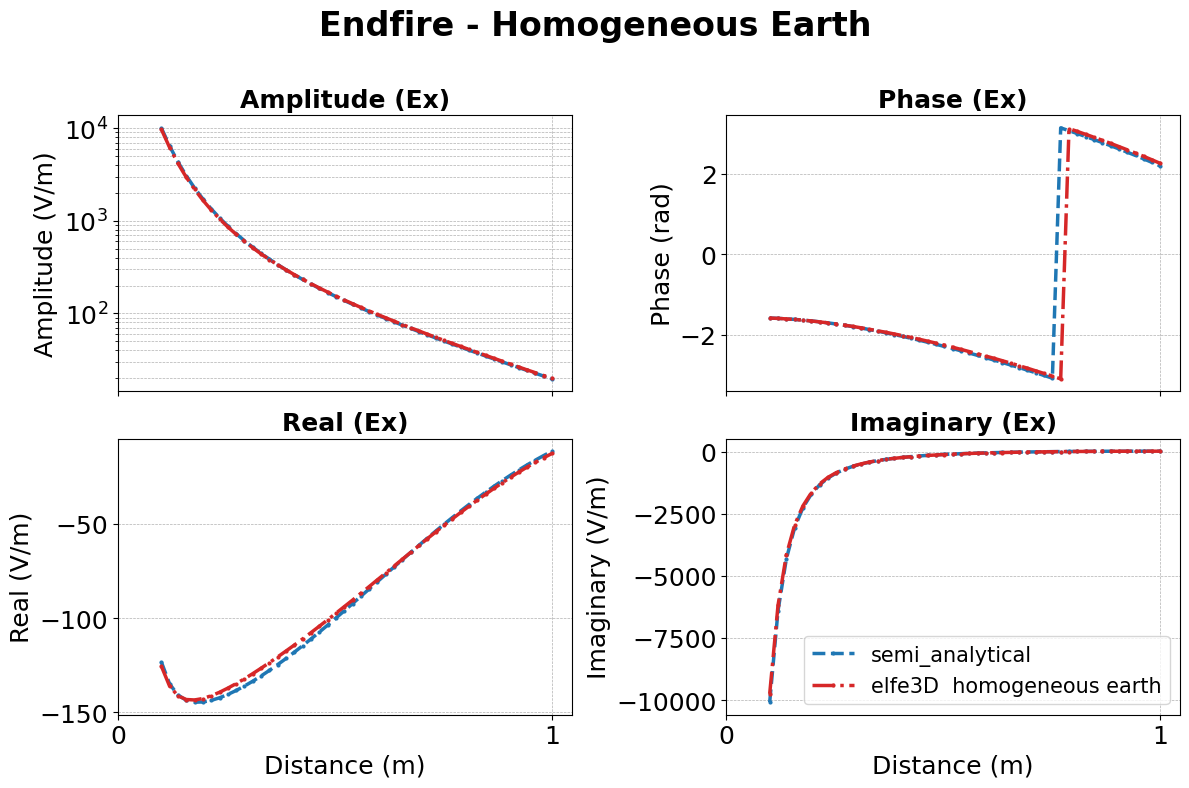

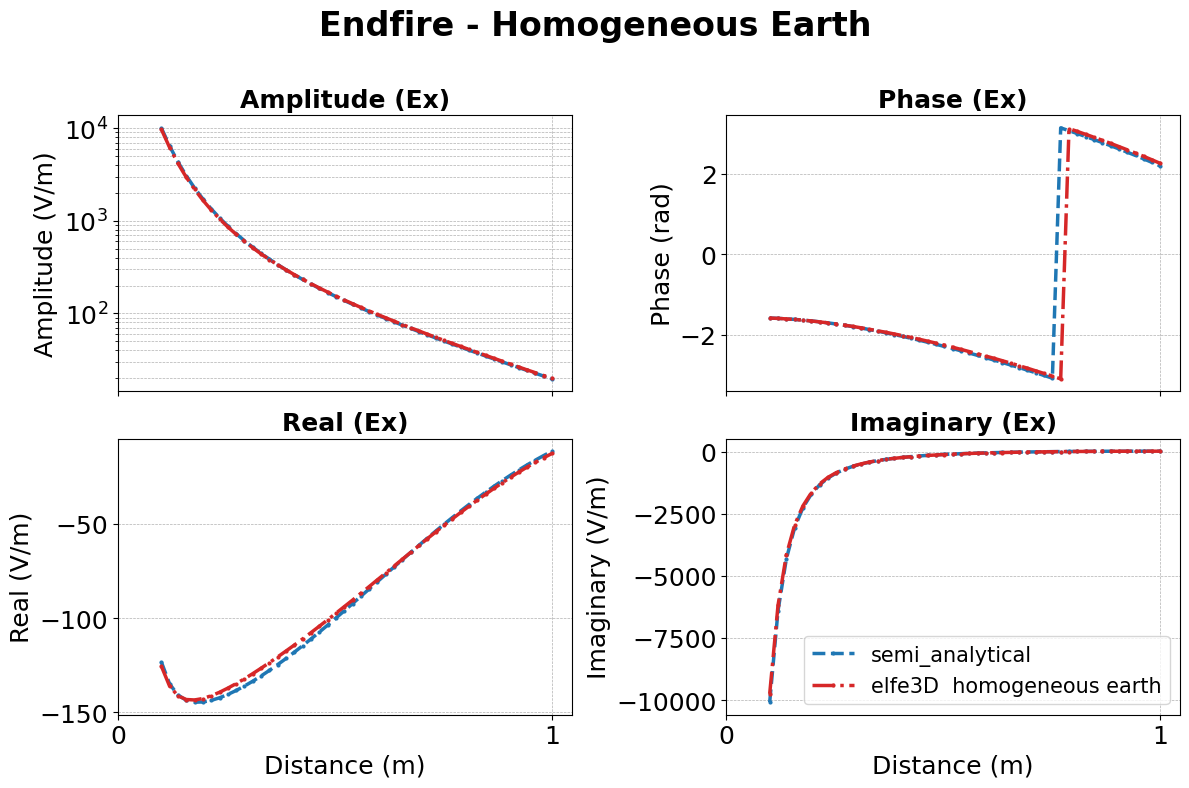

In [8]:
ReceiverLinePlot([semi_analytical, ef]).plot(suptitle="Endfire - Homogeneous Earth")

## Error plot

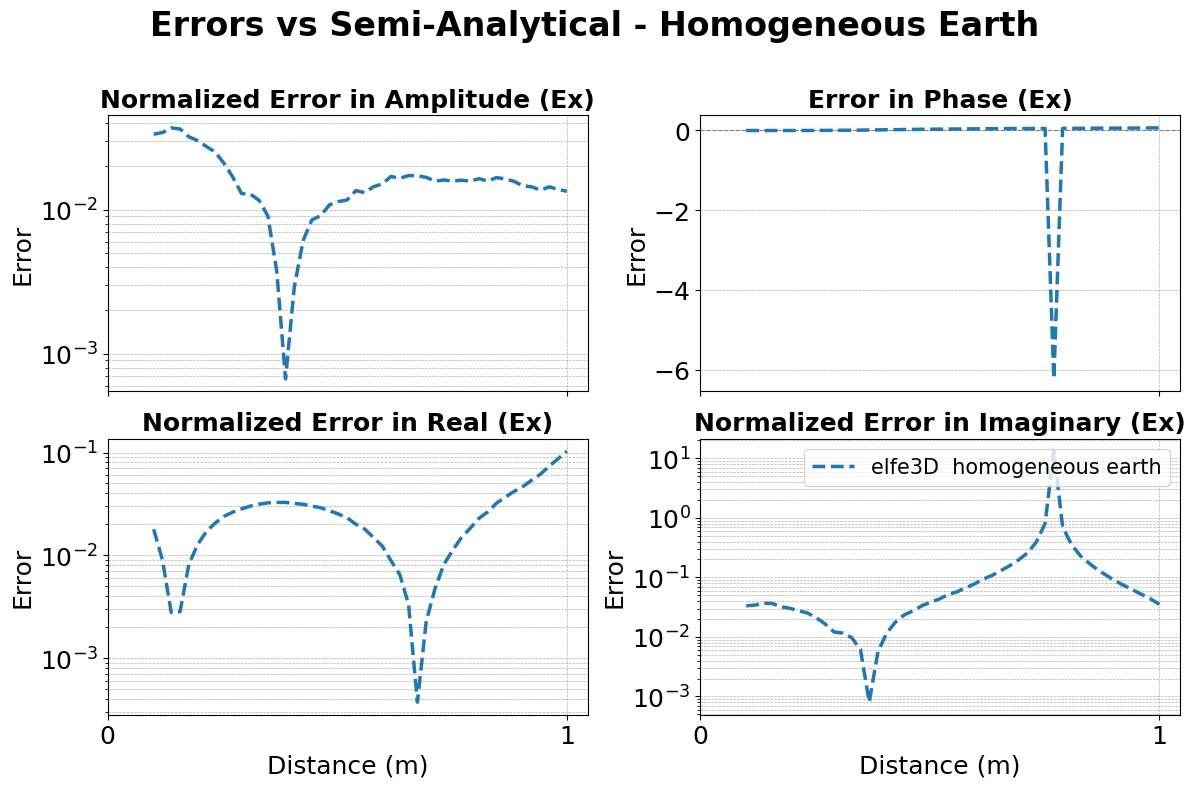

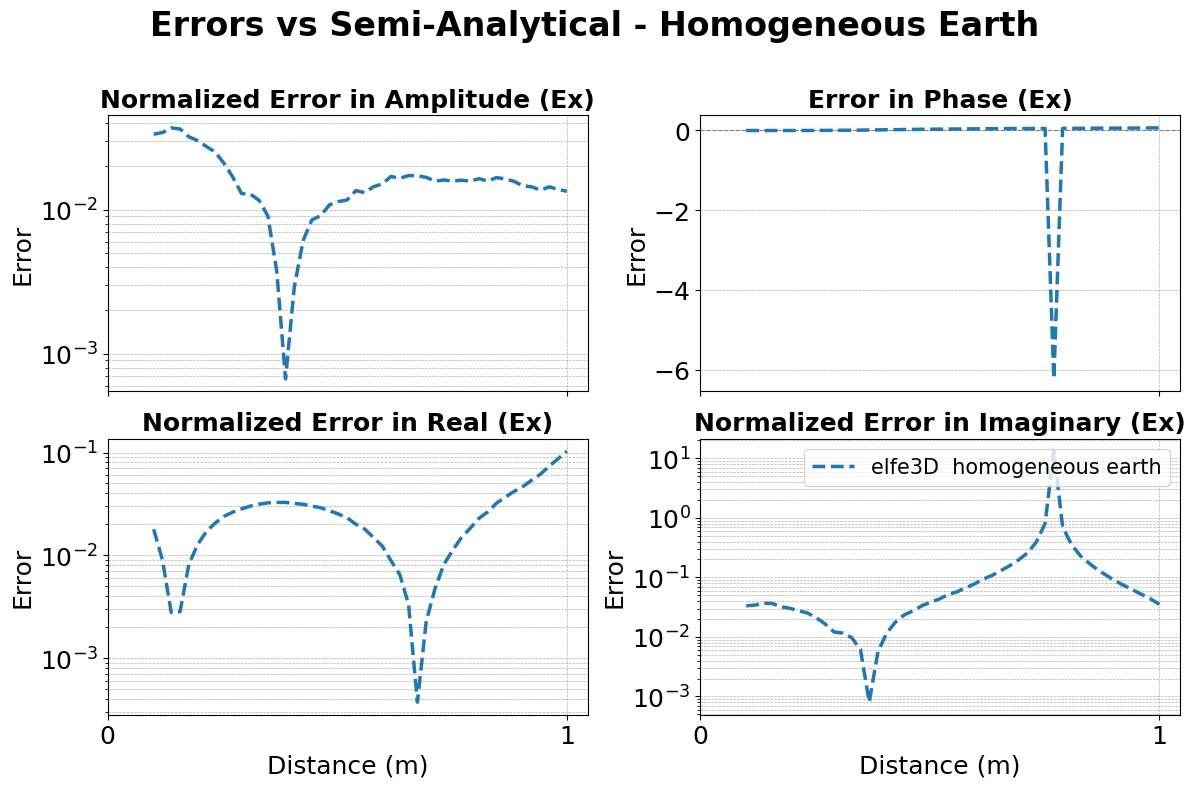

In [9]:
ReceiverLineErrorPlot([ef], reference=semi_analytical).plot(suptitle="Errors vs Semi-Analytical - Homogeneous Earth")

## Combined (fields + errors)

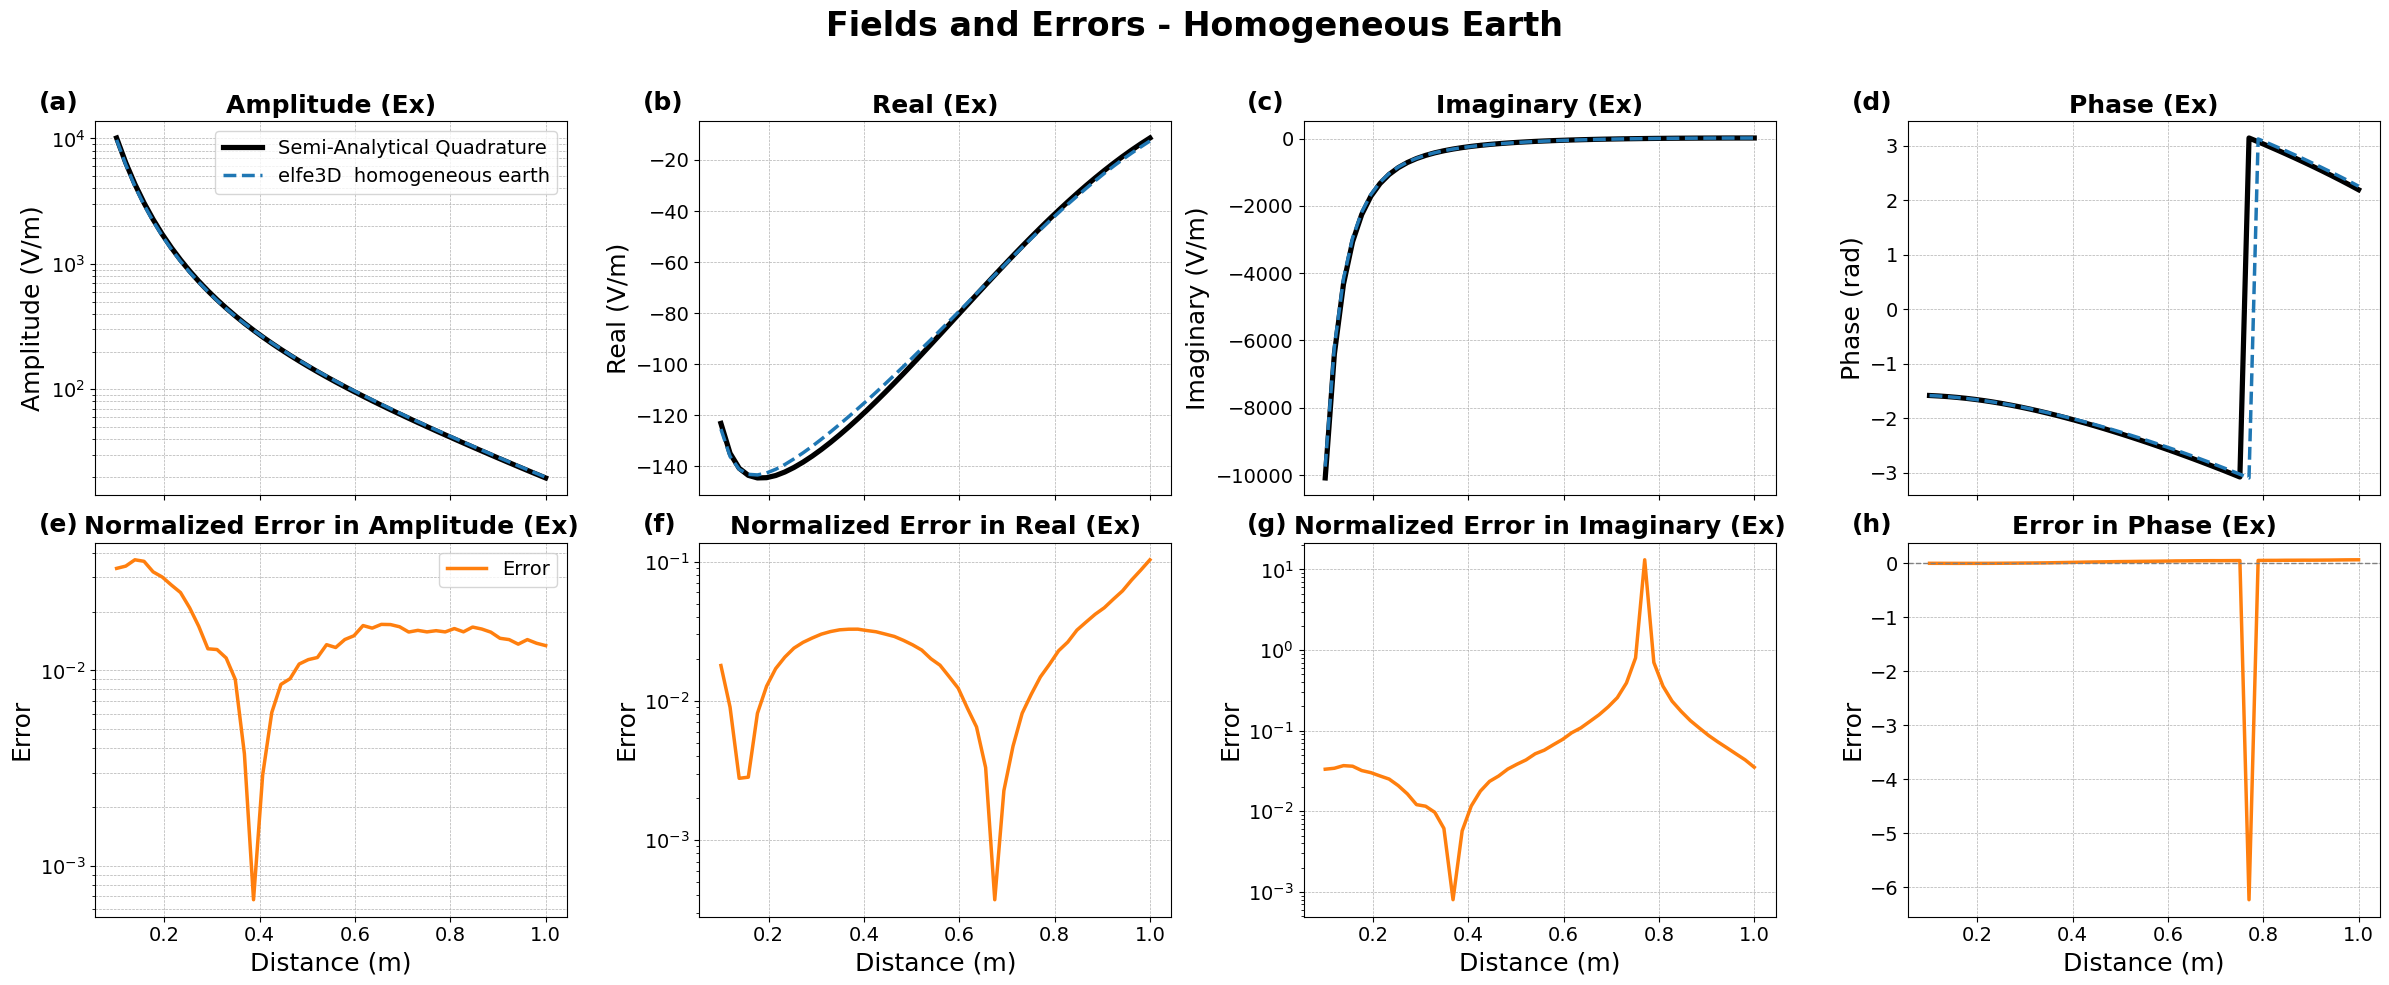

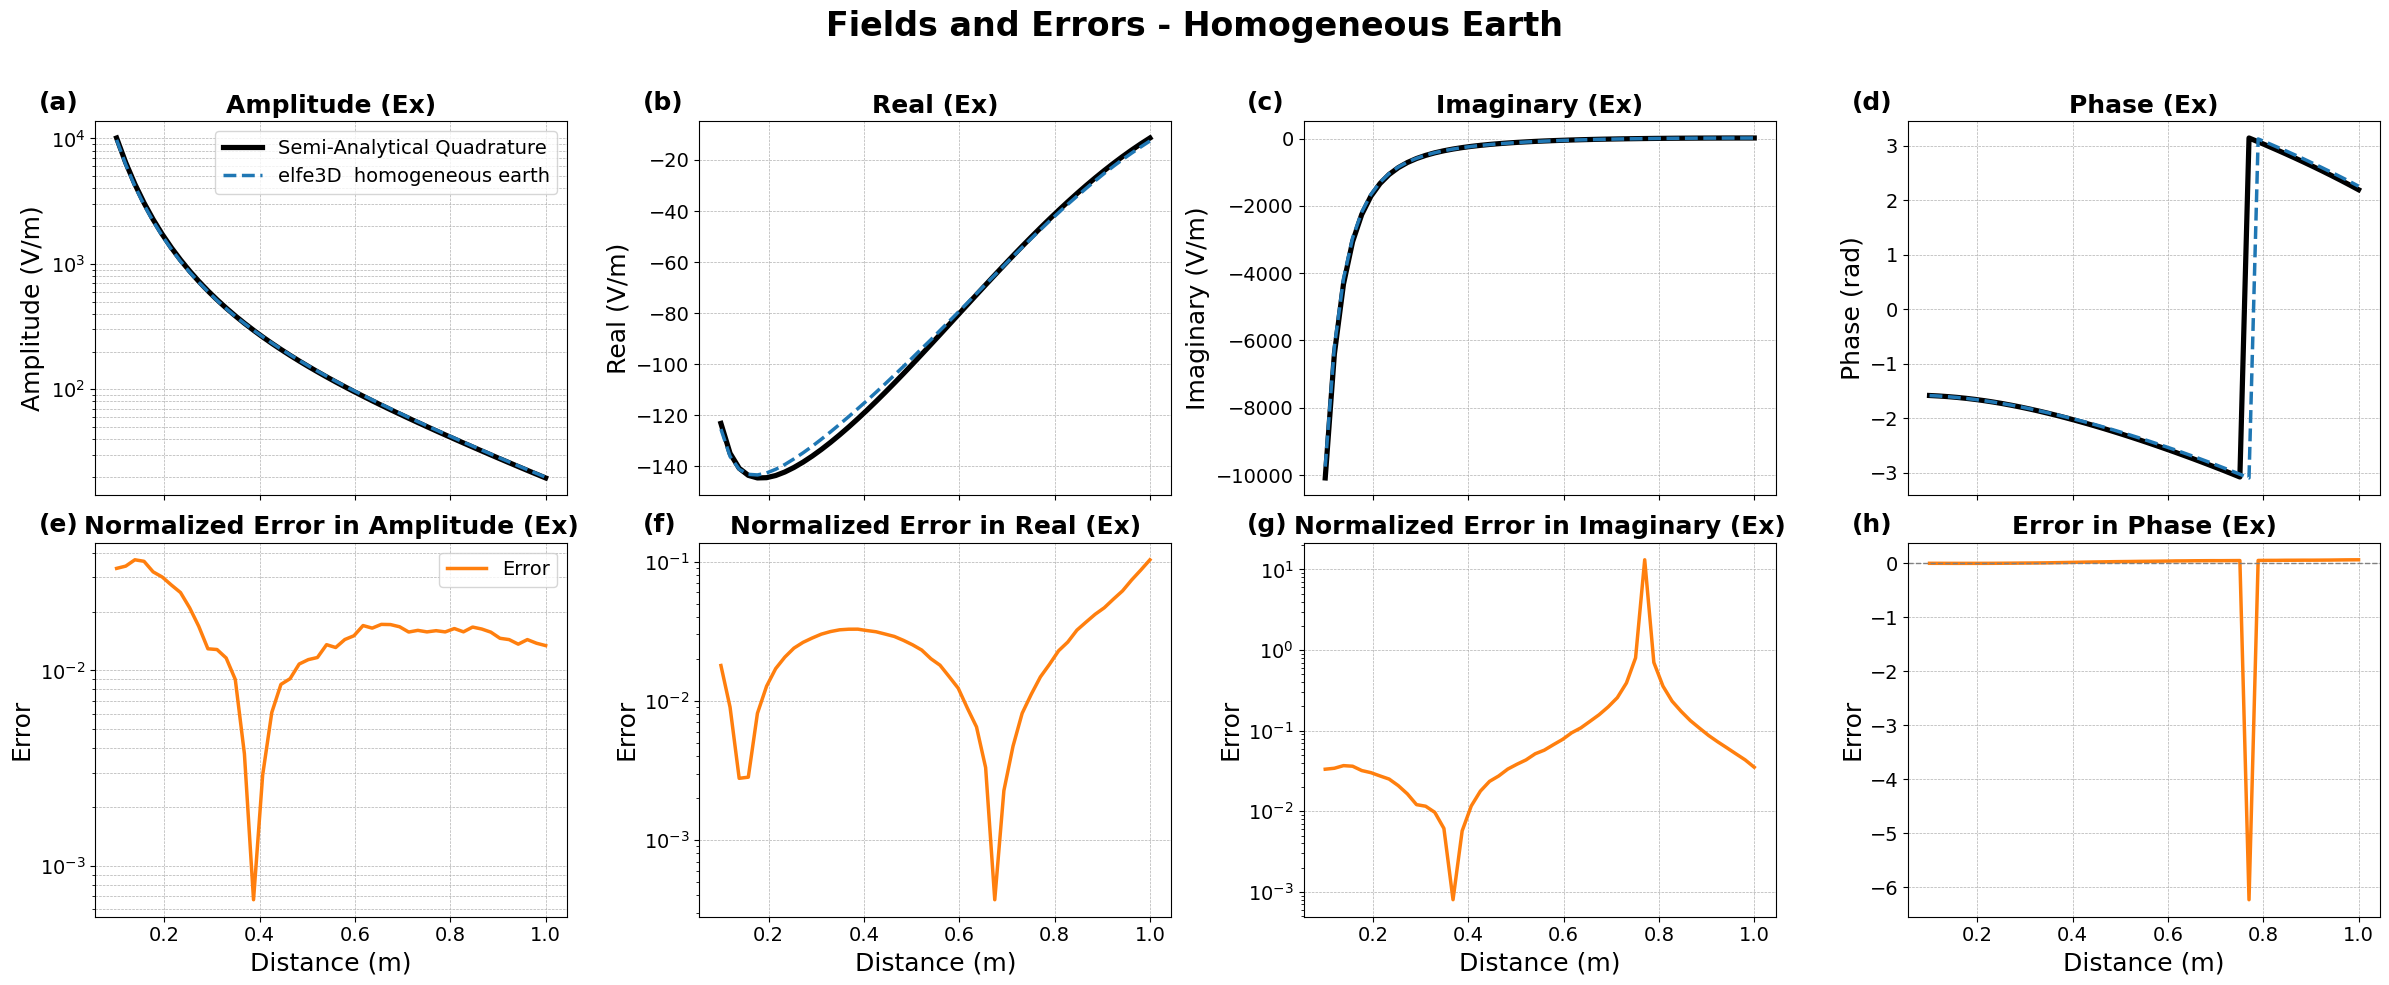

In [10]:
ReceiverLineCombined(ef, semi_analytical).plot(suptitle="Fields and Errors - Homogeneous Earth")

## Error histogram

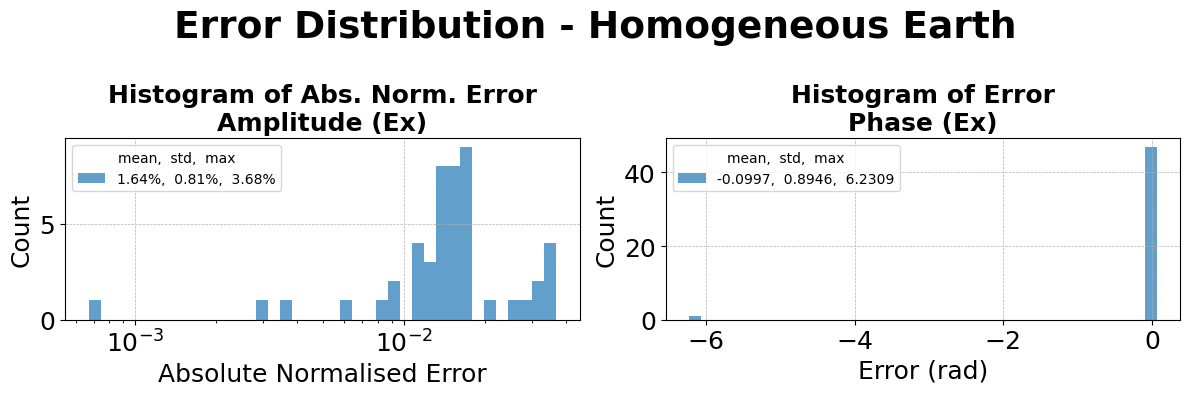

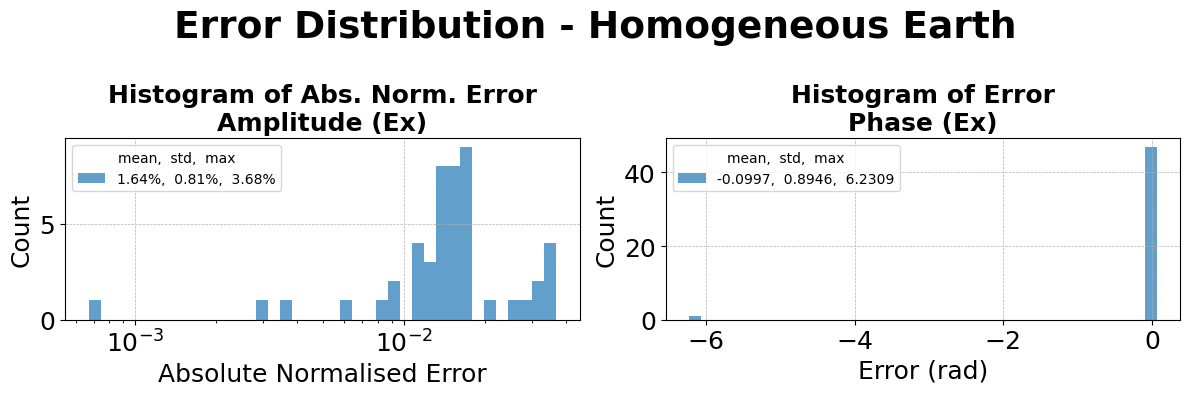

In [11]:
ErrorHistogramPlot([ef], reference=semi_analytical).plot(suptitle="Error Distribution - Homogeneous Earth")

## Printed error summary

In [12]:
qty_names = ['Amplitude', 'Phase', 'Real', 'Imaginary']
print(f'\n── {ef.label} ──')
for qi, name in enumerate(qty_names):
    err = field_error(semi_analytical, ef, qi)
    m, s, mx = error_stats(err)
    scale, unit = (100, '%') if qi != 1 else (1, 'rad')
    print(f'  {name:12s}:  mean={m*scale:.3f}{unit}  '
          f'std={s*scale:.3f}{unit}  max={mx*scale:.3f}{unit}')



── elfe3D  homogeneous earth ──
  Amplitude   :  mean=1.643%  std=0.806%  max=3.684%
  Phase       :  mean=-0.100rad  std=0.895rad  max=6.231rad
  Real        :  mean=2.618%  std=2.099%  max=10.307%
  Imaginary   :  mean=37.868%  std=187.559%  max=1319.034%
